# C-MAPSS 数据探索 —— 传感器特征重要性分析

**目标**：使用随机森林（Random Forest）在 FD001 训练集上，以传感器数据为输入、RUL 为标签，提取各传感器特征重要性。结论将硬编码到 `configs/config.py` 中，指导后续预处理中剔除无用传感器。

In [1]:
# ============================================================
# 第1步：导入依赖库
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✅ 依赖库导入成功！")

✅ 依赖库导入成功！


In [2]:
# ============================================================
# 第2步：加载 FD001 训练数据并定义列名
# ============================================================
# C-MAPSS 数据的 26 列含义：
#   [0] unit        - 发动机编号
#   [1] cycle       - 运行周期（时间步）
#   [2] op_setting1 - 操作参数 1
#   [3] op_setting2 - 操作参数 2
#   [4] op_setting3 - 操作参数 3
#   [5~25]          - 21 个传感器测量值 (sensor_1 ~ sensor_21)

column_names = [
    'unit', 'cycle',
    'op1', 'op2', 'op3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5',
    'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21'
]

# 读取 FD001 训练数据（数据以空格分隔）
df_train = pd.read_csv('../data/raw/train_FD001.txt', sep='\s+', header=None)
df_train.columns = column_names

print(f"📊 FD001 训练集：{df_train.shape[0]} 行 × {df_train.shape[1]} 列")
print(f"🔢 发动机数量：{df_train['unit'].nunique()}")
df_train.head()

📊 FD001 训练集：20631 行 × 26 列
🔢 发动机数量：100


,unit,cycle,op1,op2,op3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
# ============================================================
# 第3步：计算 RUL 标签
# ============================================================
# RUL = 该发动机的最大 cycle - 当前 cycle
# 例如：某发动机运行了 200 个周期后失效，
#   第 1 周期 RUL=199, 第 200 周期 RUL=0
max_cycle_per_unit = df_train.groupby('unit')['cycle'].max()
df_train['RUL'] = df_train['unit'].map(max_cycle_per_unit) - df_train['cycle']

print(f"✅ RUL 标签已计算")
print(f"   RUL 范围: [{df_train['RUL'].min()}, {df_train['RUL'].max()}]")
print(f"   平均 RUL: {df_train['RUL'].mean():.1f}")
df_train[['unit', 'cycle', 'RUL']].head()

✅ RUL 标签已计算
   RUL 范围: [0, 361]
   平均 RUL: 107.8


,unit,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


In [4]:
# ============================================================
# 第4步：识别无效传感器（方差为0或接近0的列）
# ============================================================
# 这些列在整个数据集中是常数或近乎常数，对预测没有帮助
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]  # sensor_1 ~ sensor_21
op_cols = ['op1', 'op2', 'op3']

# 计算每个传感器列的方差
variances = df_train[sensor_cols + op_cols].var()
print("=" * 60)
print("各传感器/操作参数列的方差：")
print("=" * 60)

low_var_threshold = 1e-5  # 方差阈值：低于此值视为无效
invalid_cols = []          # 记录要剔除的列
valid_cols = []            # 记录保留的列

for col in sensor_cols + op_cols:
    var = variances[col]
    status = "❌ 剔除 (常数/近常数)" if var < low_var_threshold else "✅ 保留"
    if var < low_var_threshold:
        invalid_cols.append(col)
    else:
        valid_cols.append(col)
    print(f"  {col:12s}  方差 = {var:.6e}   {status}")

print(f"\n📌 保留的特征列数：{len(valid_cols)}")
print(f"📌 剔除的无用列数：{len(invalid_cols)}")
print(f"   剔除列名：{invalid_cols}")

各传感器/操作参数列的方差：
  sensor_1      方差 = 0.000000e+00   ❌ 剔除 (常数/近常数)
  sensor_2      方差 = 2.500533e-01   ✅ 保留
  sensor_3      方差 = 3.759099e+01   ✅ 保留
  sensor_4      方差 = 8.101089e+01   ✅ 保留
  sensor_5      方差 = 3.155597e-30   ❌ 剔除 (常数/近常数)
  sensor_6      方差 = 1.929279e-06   ❌ 剔除 (常数/近常数)
  sensor_7      方差 = 7.833883e-01   ✅ 保留
  sensor_8      方差 = 5.038938e-03   ✅ 保留
  sensor_9      方差 = 4.876536e+02   ✅ 保留
  sensor_10     方差 = 0.000000e+00   ❌ 剔除 (常数/近常数)
  sensor_11     方差 = 7.133568e-02   ✅ 保留
  sensor_12     方差 = 5.439850e-01   ✅ 保留
  sensor_13     方差 = 5.172330e-03   ✅ 保留
  sensor_14     方差 = 3.639005e+02   ✅ 保留
  sensor_15     方差 = 1.406628e-03   ✅ 保留
  sensor_16     方差 = 1.926023e-34   ❌ 剔除 (常数/近常数)
  sensor_17     方差 = 2.398667e+00   ✅ 保留
  sensor_18     方差 = 0.000000e+00   ❌ 剔除 (常数/近常数)
  sensor_19     方差 = 0.000000e+00   ❌ 剔除 (常数/近常数)
  sensor_20     方差 = 3.266927e-02   ✅ 保留
  sensor_21     方差 = 1.171825e-02   ✅ 保留
  op1           方差 = 4.784340e-06   ❌ 剔除 (常数/近常数)
  op2      

In [5]:
# ============================================================
# 第5步：随机森林特征重要性分析
# ============================================================
# 用保留的有效特征作为输入 X，RUL 作为标签 y
# 训练 RandomForestRegressor，提取 feature_importances_

X = df_train[valid_cols].values    # 特征矩阵
y = df_train['RUL'].values          # RUL 标签

print(f"特征矩阵 X 形状: {X.shape}")
print(f"标签向量 y 形状: {y.shape}")

# 训练随机森林（100棵树，固定随机种子保证可复现）
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1           # 并行加速
)
rf.fit(X, y)

# 获取特征重要性
importances = rf.feature_importances_

# 创建排序后的 DataFrame
importance_df = pd.DataFrame({
    '特征': valid_cols,
    '重要性': importances
}).sort_values('重要性', ascending=False)

print(f"\n📊 随机森林 R² Score（训练集）: {rf.score(X, y):.4f}")
print(f"\n特征重要性排名：")
print(importance_df.to_string(index=False))

特征矩阵 X 形状: (20631, 14)
标签向量 y 形状: (20631,)

📊 随机森林 R² Score（训练集）: 0.8634

特征重要性排名：
       特征      重要性
sensor_11 0.487743
 sensor_9 0.133099
 sensor_4 0.096708
sensor_12 0.042788
 sensor_7 0.035127
sensor_14 0.034632
sensor_15 0.029949
sensor_21 0.028076
 sensor_3 0.024384
 sensor_2 0.023748
sensor_20 0.019696
sensor_13 0.018531
 sensor_8 0.017593
sensor_17 0.007925


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

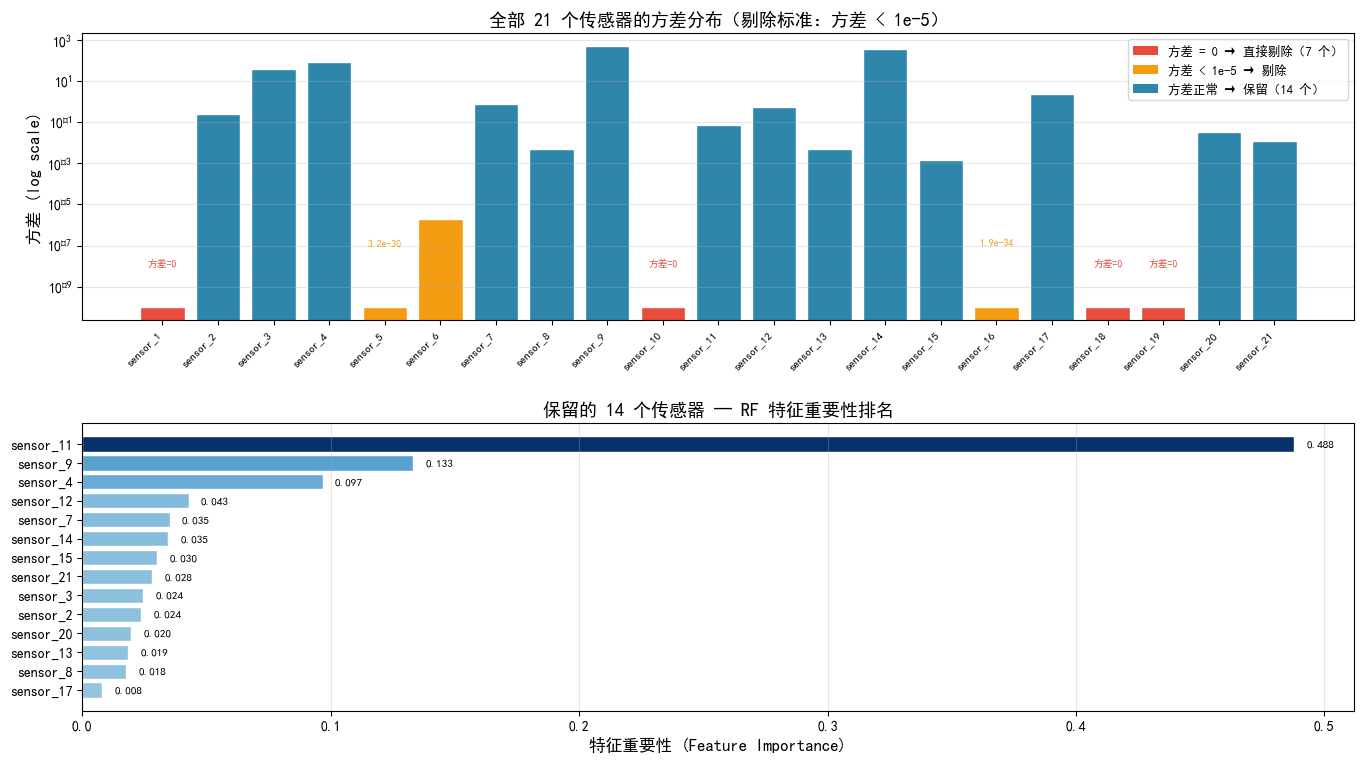

✅ 全貌对比图已保存为 notebooks/feature_importance.png


In [8]:
# ============================================================
# 第6步：可视化 —— 全貌对比图（双面板）
# ============================================================
# 上图：全部 21 个传感器的方差（对数坐标），红/橙/蓝标记剔除/保留
# 下图：保留的 14 个传感器的 RF 特征重要性（水平条形图）

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# ========================
# 上图：21 个传感器的方差全景
# ========================
all_sensor_names = [f'sensor_{i}' for i in range(1, 22)]
all_variances = df_train[all_sensor_names].var().values

# 按方差三档着色
colors_var = []
for v in all_variances:
    if v == 0.0:
        colors_var.append('#E74C3C')      # 红色：方差严格为 0
    elif v < 1e-5:
        colors_var.append('#F39C12')      # 橙色：方差 ≈ 0
    else:
        colors_var.append('#2E86AB')      # 蓝色：正常传感器

ax1.bar(range(21), all_variances + 1e-10, color=colors_var, edgecolor='white')
ax1.set_yscale('log')
ax1.set_xticks(range(21))
ax1.set_xticklabels(all_sensor_names, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('方差 (log scale)', fontsize=12)
ax1.set_title('全部 21 个传感器的方差分布（剔除标准：方差 < 1e-5）', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 在剔除的柱子上标注原因
for i, v in enumerate(all_variances):
    if v == 0.0:
        ax1.text(i, 1e-8, '方差=0', ha='center', fontsize=7,
                 color='#E74C3C', fontweight='bold')
    elif v < 1e-5:
        ax1.text(i, 1e-7, f'{v:.1e}', ha='center', fontsize=7, color='#F39C12')

from matplotlib.patches import Patch
legend_var = [
    Patch(facecolor='#E74C3C', label='方差 = 0 → 直接剔除（7 个）'),
    Patch(facecolor='#F39C12', label='方差 < 1e-5 → 剔除'),
    Patch(facecolor='#2E86AB', label='方差正常 → 保留（14 个）'),
]
ax1.legend(handles=legend_var, loc='upper right', fontsize=9)

# ========================
# 下图：保留传感器的 RF 重要性
# ========================
importance_values = importance_df['重要性'].values
norm = plt.Normalize(importance_values.min(), importance_values.max())
colors_imp = plt.cm.Blues(0.4 + 0.6 * norm(importance_values))

ax2.barh(range(len(importance_df)), importance_values, color=colors_imp, edgecolor='white')
ax2.set_yticks(range(len(importance_df)))
ax2.set_yticklabels(importance_df['特征'], fontsize=10)
ax2.invert_yaxis()
ax2.set_xlabel('特征重要性 (Feature Importance)', fontsize=12)
ax2.set_title('保留的 14 个传感器 — RF 特征重要性排名', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

for i, (_, row) in enumerate(importance_df.iterrows()):
    ax2.text(row['重要性'] + 0.005, i, f"{row['重要性']:.3f}",
             va='center', fontsize=8)

plt.tight_layout(pad=2)
plt.savefig('../notebooks/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 全貌对比图已保存为 notebooks/feature_importance.png")

In [7]:
# ============================================================
# 第7步：结论 —— 确定最终保留的传感器列表
# ============================================================
# 规则：
#   1. 首先剔除方差 ≈ 0 的列（已在第4步识别）
#   2. 再剔除特征重要性 < 0.005 的传感器
#   3. 保留操作参数 op1, op2, op3（虽然 op3 方差=0，但在多工况 FD002~FD004 中有变化）

importance_threshold = 0.005  # 重要性阈值

# 从重要性 DataFrame 中筛选
selected = importance_df[importance_df['重要性'] >= importance_threshold]
selected_names = selected['特征'].tolist()

# 加上操作参数（在多工况场景下有用）
final_sensor_list = [col for col in selected_names if 'sensor' in col]

# 计算原始列索引（用于直接从 txt 文件按索引选择）
sensor_indices_in_raw = []
for sensor_name in final_sensor_list:
    sensor_num = int(sensor_name.split('_')[1])  # sensor_X -> X
    raw_col_idx = 4 + sensor_num                  # col 0~4 是 unit/cycle/op1~3
    sensor_indices_in_raw.append(raw_col_idx)

print("=" * 60)
print("📋 最终结论（将硬编码到 configs/config.py）：")
print("=" * 60)
print(f"\n最终保留的传感器 ({len(final_sensor_list)} 个)：")
print(f"  传感器名：{final_sensor_list}")
print(f"  原始列索引 (0-based)：{sensor_indices_in_raw}")
print(f"\n最终保留的操作参数：['op1', 'op2', 'op3']")
print(f"  （op3 在 FD001 中方差为 0，但在 FD002~FD004 中有变化）")
print(f"\n特征矩阵维度：[样本数, {len(final_sensor_list) + 3}]")
print(f"  (即 {len(final_sensor_list)} 个保留传感器 + 3 个操作参数)")

# 输出可复制到 config.py 的代码
print("\n" + "=" * 60)
print("📝 可复制到 configs/config.py 的代码：")
print("=" * 60)
print(f"""
# 保留的传感器索引（0-based，对应原始 26 列）
KEPT_SENSOR_INDICES = {sensor_indices_in_raw}

# 保留的传感器名称
KEPT_SENSOR_NAMES = {final_sensor_list}

# 是否保留操作参数（op1, op2, op3）
KEEP_OPERATIONAL_SETTINGS = True
""")

📋 最终结论（将硬编码到 configs/config.py）：

最终保留的传感器 (14 个)：
  传感器名：['sensor_11', 'sensor_9', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_14', 'sensor_15', 'sensor_21', 'sensor_3', 'sensor_2', 'sensor_20', 'sensor_13', 'sensor_8', 'sensor_17']
  原始列索引 (0-based)：[15, 13, 8, 16, 11, 18, 19, 25, 7, 6, 24, 17, 12, 21]

最终保留的操作参数：['op1', 'op2', 'op3']
  （op3 在 FD001 中方差为 0，但在 FD002~FD004 中有变化）

特征矩阵维度：[样本数, 17]
  (即 14 个保留传感器 + 3 个操作参数)

📝 可复制到 configs/config.py 的代码：

# 保留的传感器索引（0-based，对应原始 26 列）
KEPT_SENSOR_INDICES = [15, 13, 8, 16, 11, 18, 19, 25, 7, 6, 24, 17, 12, 21]

# 保留的传感器名称
KEPT_SENSOR_NAMES = ['sensor_11', 'sensor_9', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_14', 'sensor_15', 'sensor_21', 'sensor_3', 'sensor_2', 'sensor_20', 'sensor_13', 'sensor_8', 'sensor_17']

# 是否保留操作参数（op1, op2, op3）
KEEP_OPERATIONAL_SETTINGS = True

